In [63]:
import torch
import math
import numpy as np

def _ensure_theta_radians(theta_grid_t):
    """If angles look like degrees (|val|>2π), convert to radians."""
    theta = theta_grid_t
    if theta.abs().max() > 2 * math.pi:
        # assume degrees
        theta = theta * (math.pi / 180.0)
    return theta

def _steering_matrix(N, theta_grid_t, device):
    """
    Returns steering matrix a(θ) of shape (N, T) using radians.
    a_n(θ) = exp(j π n sin(θ)) / sqrt(N), n=0..N-1
    """
    T = theta_grid_t.numel()
    n = torch.arange(N, device=device, dtype=torch.float32).view(N, 1)      # (N,1)
    sin_thetas = torch.sin(theta_grid_t).view(1, T).to(torch.float32)      # (1,T)

    # cast to complex for matmul/exponent
    n_c = n.to(torch.complex64)                    # (N,1)
    sin_c = sin_thetas.to(torch.complex64)         # (1,T)

    a_theta = torch.exp(1j * math.pi * (n_c @ sin_c)) / math.sqrt(float(N))  # (N,T), complex
    return a_theta  # complex64

def benchmark_beampattern_torch(Psi, theta_grid_t, N, normalize=True, device=None):
    """
    Compute benchmark beampattern B(θ) = a^H(θ) Ψ a(θ).
    - Psi: (N,N) complex or (B,N,N) batched complex
    - theta_grid_t: 1D tensor of angles (radians preferred; degrees OK — function auto-converts)
    - Returns: (B, T) real tensor (normalized per-sample if normalize=True)
    """
    # convert to tensor if needed
    if not torch.is_tensor(theta_grid_t):
        theta_grid_t = torch.tensor(theta_grid_t, dtype=torch.float32)
    theta_grid_t = _ensure_theta_radians(theta_grid_t)

    device = device or (Psi.device if torch.is_tensor(Psi) else torch.device('cpu'))

    # convert Psi to torch tensor, complex dtype
    if not torch.is_tensor(Psi):
        Psi = torch.tensor(Psi, dtype=torch.complex64, device=device)
    else:
        Psi = Psi.to(device)

    # make batched
    if Psi.ndim == 2:
        Psi_batch = Psi.unsqueeze(0)   # (1,N,N)
    else:
        Psi_batch = Psi                # (B,N,N)
    B = Psi_batch.shape[0]
    T = theta_grid_t.numel()

    a_theta = _steering_matrix(N, theta_grid_t.to(device), device)   # (N,T), complex
    # repeat steering matrix for batch: (B,N,T)
    a_batch = a_theta.unsqueeze(0).repeat(B, 1, 1)                   # (B,N,T)

    # Compute Psi @ a for each batch and theta -> (B,N,T)
    # torch.bmm expects 3D shapes so we can use it by flattening T into last dim directly:
    # S_a[b,:,t] = Psi_batch[b] @ a_batch[b,:,t], this is achieved by:
    S_a = torch.einsum('bnm,bmt->bnt', Psi_batch, a_batch)         # (B,N,T) complex

    # B_theta[b,t] = sum_n conj(a_{b,n,t}) * S_a[b,n,t]
    B_theta = torch.sum(a_batch.conj() * S_a, dim=1).real          # (B,T) real

    if normalize:
        maxv = B_theta.amax(dim=1, keepdim=True)                   # (B,1)
        B_theta = B_theta / (maxv + 1e-12)

    # squeeze if single
    if B_theta.ndim == 1:
        B_theta = B_theta.unsqueeze(0)  # ensure shape (1, T)
    return B_theta                # (B,T)


def sensing_beampattern_torch(A_batch, D_batch, theta_grid_t, normalize=True, device=None):
    """
    Compute sensing beampattern S(θ) = a^H(θ) S_cov a(θ) where S_cov = A D D^H A^H.
    - A_batch: (B, N, M) or (N, M)  (will be batched)
    - D_batch: (B, M, K) or (M, K)
    - theta_grid_t: 1D tensor of angles in radians (or degrees — auto convert)
    - Returns: (B, T) real tensor (normalized if normalize=True)
    """
    # ensure tensors
    if not torch.is_tensor(theta_grid_t):
        theta_grid_t = torch.tensor(theta_grid_t, dtype=torch.float32)
    theta_grid_t = _ensure_theta_radians(theta_grid_t)

    # device resolution
    if device is None:
        # infer from inputs
        if torch.is_tensor(A_batch):
            device = A_batch.device
        elif torch.is_tensor(D_batch):
            device = D_batch.device
        else:
            device = torch.device('cpu')

    # promote single-sample to batch
    single = False
    if A_batch.dim() == 2:
        single = True
        A_batch = A_batch.unsqueeze(0)
        D_batch = D_batch.unsqueeze(0)

    A_batch = A_batch.to(device)
    D_batch = D_batch.to(device)

    B, N, M = A_batch.shape
    T = theta_grid_t.numel()

    # steering matrix (N,T)
    a_theta = _steering_matrix(N, theta_grid_t.to(device), device)
    # make batched (B,N,T)
    a_batch = a_theta.unsqueeze(0).repeat(B, 1, 1)

    # Sensing covariance S_cov = A D D^H A^H  -> (B,N,N)
    DDH = torch.bmm(D_batch, D_batch.conj().transpose(1, 2))        # (B,M,M)
    AD = torch.bmm(A_batch, DDH)                                   # (B,N,M)
    S_cov = torch.bmm(AD, A_batch.conj().transpose(1, 2))          # (B,N,N)

    # Compute S_cov @ a for each theta: -> (B,N,T)
    S_a = torch.einsum('bnm,bmt->bnt', S_cov, a_batch)

    # Beampattern: sum_n conj(a) * (S_cov a)
    B_theta = torch.sum(a_batch.conj() * S_a, dim=1).real         # (B,T)

    if normalize:
        maxv = B_theta.amax(dim=1, keepdim=True)
        B_theta = B_theta / (maxv + 1e-12)

    if single:
        return B_theta.squeeze(0)   # (T,)
    return B_theta                 # (B,T)


Loading UPGANet J=1 (Imax=120) from upganet_J1_final.pth
Loading UPGANet J=10 (Imax=40) from upganet_J10_final.pth
Loading UPGANet J=20 (Imax=20) from upganet_J20_final.pth
grad_tau_D range: 7.578389644622803 251.03013610839844
tensor([[0.0114, 0.0114, 0.0114,  ..., 0.0114, 0.0114, 0.0114],
        [0.0114, 0.0114, 0.0114,  ..., 0.0114, 0.0114, 0.0114],
        [0.0114, 0.0114, 0.0114,  ..., 0.0114, 0.0114, 0.0114],
        ...,
        [0.0114, 0.0114, 0.0114,  ..., 0.0114, 0.0114, 0.0114],
        [0.0114, 0.0114, 0.0114,  ..., 0.0114, 0.0114, 0.0114],
        [0.0114, 0.0114, 0.0114,  ..., 0.0114, 0.0114, 0.0114]])


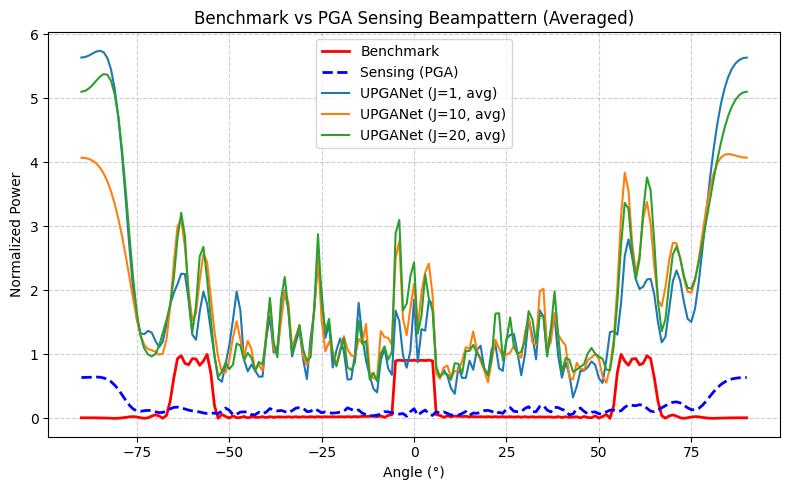

In [61]:
# === Setup ===
from lib.config import *
from lib.support_functions_torch import compute_psi, generate_channel_torch_batch, proposed_initialization_torch_batch, run_pga_torch_batch
from lib.dnn import UPGANet

num_realizations = 10
snr_db = 12

P_BS = sigma_n2 * 10 ** (snr_db / 10)
P_BS_t = torch.full((num_realizations,), P_BS, dtype=torch.float32, device=device)

# convert PSI to torch
Psi_np = compute_psi(snr_db)
Psi_t = torch.tensor(Psi_np, dtype=torch.complex64, device=device)

theta_grid_t = torch.linspace(-90, 90, 181, device=device)
Psi_batch = torch.stack([Psi_t for _ in range(num_realizations)], dim=0).to(device)

# ----------------------------
# Load trained UPGANet models
# ----------------------------
model_paths = {
    1: ("upganet_J1_final.pth", 120),
    10: ("upganet_J10_final.pth", 40),
    20: ("upganet_J20_final.pth", 20),
}

trained_nets = {}
for J, (path, Imax) in model_paths.items():
    print(f"Loading UPGANet J={J} (Imax={Imax}) from {path}")
    state = torch.load(path, map_location=device)
    net = UPGANet(N, M, K, omega, I_max=Imax, J=J).to(device)
    net.load_state_dict(state, strict=False)
    net.eval()
    trained_nets[J] = net

# === Channel generation ===
H_batch = generate_channel_torch_batch(N, M, L=L, batch_size=num_realizations, device=device)

# === Initialization ===
A0_batch, D0_batch = proposed_initialization_torch_batch(H_batch, theta_d, N, M, K, P_BS_t, device=device)

# === Run PGA ===
with torch.no_grad():
    _, _, _, A_batch, D_batch= run_pga_torch_batch(
        H=H_batch,
        A0=A0_batch,
        D0=D0_batch,
        J=10,
        I_max=I_max,
        mu=-0.01,
        lambda_=0.01,
        omega=omega,
        sigma_n2=sigma_n2,
        Psi=Psi_batch,
        P_BS=P_BS_t,
        device=device
    )

# ----------------------------
# 4) UPGANet outputs (batched) for J=1,10,20
# ----------------------------
A_up_j = {}
D_up_j = {}
for J, net in trained_nets.items():
    with torch.no_grad():
        A_out, D_out = net(H_batch, A0_batch, D0_batch, Psi_batch, torch.tensor(sigma_n2, device=device), P_BS_batch)
    A_up_j[J] = A_out   # (B,N,M)
    D_up_j[J] = D_out   # (B,M,K)


# === Compute beampatterns ===
B_bench = benchmark_beampattern_torch(Psi_batch, theta_grid_t, N, device=device)
B_sense = sensing_beampattern_torch(A_batch, D_batch, theta_grid_t, device=device)


# === Average across realizations ===
B_bench_avg = B_bench.mean(dim=0)
B_sense_avg = B_sense.mean(dim=0)

B_up_avg = {}
for J in sorted(A_up_j.keys()):
    B_j = sensing_beampattern_torch(A_up_j[J], D_up_j[J], theta_grid, device=device)  # (B,T)
    B_up_avg[J] = B_j.mean(dim=0)


# === Plot ===
plt.figure(figsize=(8,5))
plt.plot(theta_grid_t.cpu(), B_bench_avg.cpu(), 'r-', linewidth=2, label='Benchmark')
plt.plot(theta_grid_t.cpu(), B_sense_avg.cpu(), 'b--', linewidth=2, label='Sensing (PGA)')
for J in sorted(B_up_avg.keys()):
    plt.plot(theta_grid_t.cpu(), 10.0 * B_up_avg[J].cpu() + eps, label=f'UPGANet (J={J}, avg)')

plt.xlabel("Angle (°)")
plt.ylabel("Normalized Power")
plt.title("Benchmark vs PGA Sensing Beampattern (Averaged)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


Loading UPGANet J=1 (Imax=120) from upganet_J1_final.pth
Loading UPGANet J=10 (Imax=40) from upganet_J10_final.pth
Loading UPGANet J=20 (Imax=20) from upganet_J20_final.pth
grad_tau_D range: 5.3239593505859375 205.79409790039062


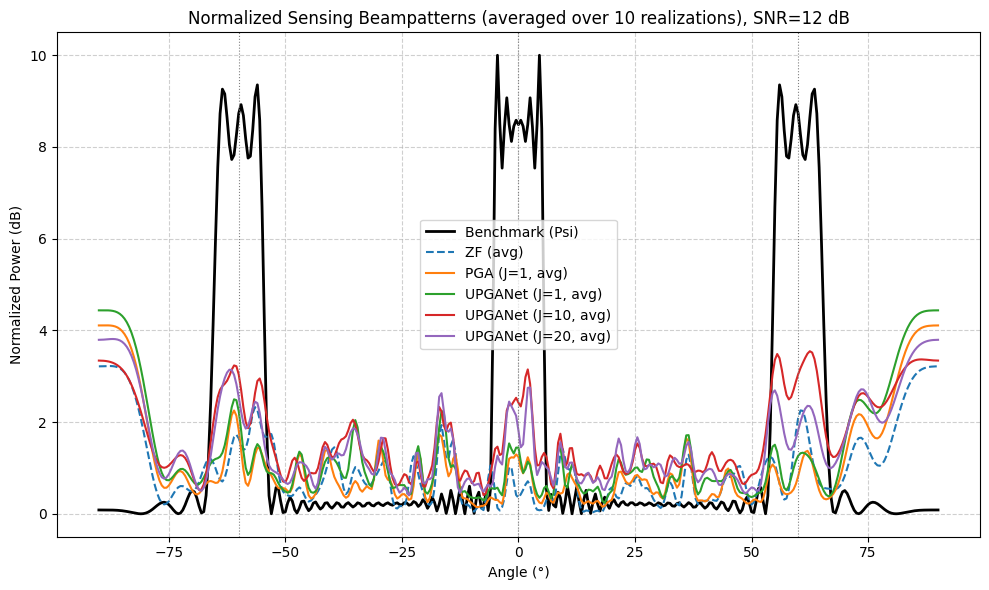

In [72]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt

# your libs (adjust import paths if needed)
from lib.dnn import UPGANet
from lib.support_functions_torch import (
    generate_channel_torch_batch,
    proposed_initialization_torch_batch,
    run_pga_torch_batch,
    compute_rate_torch,
    compute_psi
)
 # <-- change to actual module

# ----------------------------
# Parameters (change as needed)
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N, M, K = 64, 4, 4
omega = 0.3
sigma_n2 = 1.0
L = 20

# I_max per method
I_max_common = 120   # for PGA and UPGANet J=1
I_max_J10 = 40       # for UPGANet J=10
I_max_J20 = 20       # for UPGANet J=20

# evaluation batch and SNR
num_realizations = 10
snr_db_plot = 12      # single SNR at which to show beampatterns (you can loop if you want)
P_BS = sigma_n2 * 10 ** (snr_db_plot / 10)

# angular grid (radians)
theta_grid = torch.linspace(-math.pi/2, math.pi/2, 361, device=device)  # high-res grid
theta_deg = theta_grid.cpu().numpy() * 180.0 / math.pi

# desired sensing directions (if you want to mark them)
theta_d_deg = np.array([-60, 0, 60])

# ----------------------------
# Load trained UPGANet models
# ----------------------------
model_paths = {
    1: ("upganet_J1_final.pth", I_max_common),
    10: ("upganet_J10_final.pth", I_max_J10),
    20: ("upganet_J20_final.pth", I_max_J20),
}

trained_nets = {}
for J, (path, Imax) in model_paths.items():
    print(f"Loading UPGANet J={J} (Imax={Imax}) from {path}")
    state = torch.load(path, map_location=device)
    net = UPGANet(N, M, K, omega, I_max=Imax, J=J).to(device)
    net.load_state_dict(state, strict=False)
    net.eval()
    trained_nets[J] = net

# ----------------------------
# Generate batch & initializations
# ----------------------------
H_batch = generate_channel_torch_batch(N, M, L=L, batch_size=num_realizations, device=device)  # (B, M, N)
P_BS_batch = torch.full((num_realizations,), P_BS, dtype=torch.float32, device=device)

# Proposed initialization (batched)
# theta_d_t = torch.tensor(theta_d_deg, dtype=torch.float32, device=device)
A0_batch, D0_batch = proposed_initialization_torch_batch(H_batch, theta_d_t, N, M, K, P_BS_batch, device=device)

# Psi benchmark (same for all in batch)
Psi_np = compute_psi(snr_db_plot)               # returns numpy (N,N) or similar
Psi_t = torch.tensor(Psi_np, dtype=torch.complex64, device=device)
Psi_batch = Psi_t.unsqueeze(0).repeat(num_realizations, 1, 1)

# ----------------------------
# 1) Benchmark beampattern from Psi
# ----------------------------
B_bench_batch = benchmark_beampattern_torch(Psi_batch, theta_grid, N, device=device)  # (B, T)
B_bench_avg = B_bench_batch.mean(dim=0)  # (T,)



# ----------------------------
# 2) ZF baseline (fully digital) -> produce A_zf = I_N, D_zf per-sample
# ----------------------------
# We treat A_zf as identity analog (no constraint) and compute digital precoder per sample.
A_zf = torch.eye(N, dtype=torch.complex64, device=device).unsqueeze(0).repeat(num_realizations, 1, 1)  # (B,N,N) but we'll use only (B,N,N) for sensing fns expect (B,N,M) with M maybe K
# For hybrid-aware sensing function we expect A_batch shape (B,N,M). For ZF treat analog as identity and
# digital D_zf shape (B,N,K) so that A @ D -> (B,N,K)
# compute D_zf per sample (fully digital ZF): D = H^H (H H^H)^(-1) scaled to power
D_zf_list = []
for b in range(num_realizations):
    H = H_batch[b]                # (M, N) or (K,N) depending on your channel shape; adapt if necessary
    # adjust dims if H is (M,N) or (K,N) - expected H is (M,N) in your code: check generate_channel function
    # We'll treat effective user channel matrix as H_users shape (K, N). If H has M rows (==K here) it's fine.
    H_users = H[:K, :]            # (K,N)
    # D_zf (N x K) = H_users^H @ pinv(H_users @ H_users^H)
    # Use torch (on CPU/GPU)
    Hh = H_users.conj().T         # (N, K)
    inv_term = torch.linalg.pinv(H_users @ Hh)   # (K,K)
    D_zf_np = Hh @ inv_term       # (N, K) unnormalized
    # scale to satisfy total power P_BS
    norm_AD = torch.linalg.norm(D_zf_np, ord='fro')   # since A = I_N
    D_zf_scaled = D_zf_np * (math.sqrt(P_BS) / (norm_AD + 1e-12))
    D_zf_list.append(D_zf_scaled)
D_zf_batch = torch.stack(D_zf_list, dim=0).to(torch.complex64)   # (B, N, K)
# For sensing function we want A_batch shape (B,N,M). Here A for ZF is identity but has N columns;
# to match sensing_beampattern_torch which expects A_batch (B,N,M) and D_batch (B,M,K),
# we can set A_zf_small = I_N[:, :M] (N x M) and D_zf_small = D_zf_batch[:, :M, :] if dimensions mismatch.
# A simpler approach: call sensing_beampattern_torch with A_batch = I_NxN and D_batch = D_zf_batch
# (the function supports any M; ensure signature matches your implementation).
A_zf_batch = torch.eye(N, dtype=torch.complex64, device=device).unsqueeze(0).repeat(num_realizations, 1, 1)  # (B,N,N)
# NOTE: if sensing_beampattern_torch expects A shape (B,N,M) and D shape (B,M,K) with M != N, adapt accordingly.

# ----------------------------
# 3) PGA (batched)
# ----------------------------
with torch.no_grad():
    _, _, R_pga_batch, A_pga_batch, D_pga_batch = run_pga_torch_batch(
        H=H_batch,
        A0=A0_batch,
        D0=D0_batch,
        J=1,
        I_max=I_max_common,
        mu=0.01,
        lambda_=0.01,
        omega=omega,
        sigma_n2=sigma_n2,
        Psi=Psi_batch,
        P_BS=P_BS_batch,
        device=device
    )

# ----------------------------
# 4) UPGANet outputs (batched) for J=1,10,20
# ----------------------------
A_up_j = {}
D_up_j = {}
for J, net in trained_nets.items():
    with torch.no_grad():
        A_out, D_out = net(H_batch, A0_batch, D0_batch, Psi_batch, torch.tensor(sigma_n2, device=device), P_BS_batch)
    A_up_j[J] = A_out   # (B,N,M)
    D_up_j[J] = D_out   # (B,M,K)

# ----------------------------
# Compute sensing beampatterns (batched) and average
# ----------------------------
# Make sure your sensing_beampattern_torch supports the shapes passed (A_batch, D_batch).
B_pga_batch = sensing_beampattern_torch(A_pga_batch, D_pga_batch, theta_grid, device=device)  # (B,T)
B_pga_avg = B_pga_batch.mean(dim=0)

B_zf_batch = sensing_beampattern_torch(A_zf_batch, D_zf_batch, theta_grid, device=device)    # (B,T)
B_zf_avg = B_zf_batch.mean(dim=0)

B_up_avg = {}
for J in sorted(A_up_j.keys()):
    B_j = sensing_beampattern_torch(A_up_j[J], D_up_j[J], theta_grid, device=device)  # (B,T)
    B_up_avg[J] = B_j.mean(dim=0)

# ----------------------------
# Plotting
# ----------------------------
plt.figure(figsize=(10,6))
eps = 1e-12

plt.plot(theta_deg, 10.0 * B_bench_avg.cpu() + eps, label='Benchmark (Psi)', color='k', linewidth=2)
plt.plot(theta_deg, 10.0 * B_zf_avg.cpu() + eps, label='ZF (avg)', linestyle='--')
plt.plot(theta_deg, 10.0 * B_pga_avg.cpu() + eps, label='PGA (J=1, avg)')
for J in sorted(B_up_avg.keys()):
    plt.plot(theta_deg, 10.0 * B_up_avg[J].cpu() + eps, label=f'UPGANet (J={J}, avg)')

# mark desired directions
for t in theta_d_deg:
    plt.axvline(t, color='gray', linestyle=':', linewidth=0.8)

plt.xlabel('Angle (°)')
plt.ylabel('Normalized Power (dB)')
plt.title(f'Normalized Sensing Beampatterns (averaged over {num_realizations} realizations), SNR={snr_db_plot} dB')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
